This appendix contains all Python code used for data processing, analysis, and visualization in support of the research article "Health Care Utilization and Immigration Enforcement."

# Environment Setup

Import required libraries.

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sodapy import Socrata
import janitor
import requests
import pandas as pd
from bs4 import BeautifulSoup
import time
from pathlib import Path
import zipcodes

# Data Loading

Load the datasets for analysis.

## CDC PLACES: Routine checkup within the past year among adults (outcome, 2018-2023)

This data is available from CDC's PLACES data and provides information on the percentage of adults who reported having a routine checkup within the past year, broken down by county, zip, census tract, and year from 2020-2025 (data years from 2018-2023). This dataset will serve as our primary outcome variable, allowing us to assess health care utilization patterns in relation to local enforcement intensity.

Load PLACES: Local Data for Better Health:

- 2025 releases (2023 data):
    - [Census Tract Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-Census-Tract-D/cwsq-ngmh/about_data)

    - [County Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-County-Data-20/swc5-untb/about_data)

    - [ZCTA Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-ZCTA-Data-2025/qnzd-25i4/about_data)

- 2024 releases (2022 data):
    - [Census Tract Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-Census-Tract-D/ai6z-tcin/about_data)

    - [County Data](https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-County-Data-20/fu4u-a9bh/about_data)

    - [ZCTA Data](https://catalog.data.gov/dataset/places-local-data-for-better-health-zcta-data-2024-release)

- 2023 releases (2021 data):
    - [Census Tract Data](https://data.cdc.gov/d/em5e-5hvn)

    - [County Data](https://data.cdc.gov/d/h3ej-a9ec)

    - [ZCTA Data](https://data.cdc.gov/d/9umn-c3jf)

- 2022 releases (2020 data):
    - [Census Tract Data](https://data.cdc.gov/d/nw2y-v4gm)

    - [County Data](https://data.cdc.gov/d/duw2-7jbt)

    - [ZCTA Data](https://data.cdc.gov/d/gd4x-jyhw)

- 2021 releases (2019 data):
    - [Census Tract Data](https://data.cdc.gov/d/373s-ayzu)

    - [County Data](https://data.cdc.gov/d/pqpp-u99h)

    - [ZCTA Data](https://data.cdc.gov/d/s85h-9xpy)

- 2020 releases (2018 data):
    - [Census Tract Data](https://data.cdc.gov/d/4ai3-zynv)

    - [County Data](https://data.cdc.gov/d/dv4u-3x3q)

    - [ZCTA Data](https://data.cdc.gov/d/fbbf-hgkc)

> Note: Data released each year reflects BRFSS data from 2 years prior. For e.g., 2025 release reflects 2023 BRFSS data. 2016-2019 release data is also available, but data format is not consistent.

> NOTE: try looking for demographic data from PLACES (e.g., race/ethnicity etc.)

In [3]:
# Load CDC PLACES data
# Data source: CDC PLACES
# Time period: 2018-2023
# Geographic levels: County, ZIP code, Census tract

file_templates = {
    "census": "Data/PLACES__Local_Data_for_Better_Health,_Census_Tract_Data_{release}_release.csv",
    "county": "Data/PLACES__Local_Data_for_Better_Health,_County_Data_{release}_release.csv",
    "zip": "Data/PLACES__Local_Data_for_Better_Health,_ZCTA_Data_{release}_release.csv",
}

for release_year in range(2025, 2019, -1):  # 2025, 2024, ..., 2020
    data_year = release_year - 2

    globals()[f"places_census_{data_year}"] = pd.read_csv(
        file_templates["census"].format(release=release_year)
    )
    globals()[f"places_county_{data_year}"] = pd.read_csv(
        file_templates["county"].format(release=release_year)
    )
    globals()[f"places_zip_{data_year}"] = pd.read_csv(
        file_templates["zip"].format(release=release_year)
    )

## TRAC: Detention Facilities Average Daily Population (predictor, 2019-2026)

Load average daily population data from ICE detention facilities. This data is at the zip level.

> Richie, I pulled this data manually from https://tracreports.org/immigration/detentionstats/facilities.html by copying and pasting it into an Excel file, but we could try scraping it instead if we want?

In [4]:
# Load TRAC detention facilities data
# Data source: TRAC (Transactional Records Access Clearinghouse), retrieved 3/19/2026
# Time period: September 30, 2019 - February 5, 2026

detention_facilities = pd.read_excel('Data/TRAC_DetentionFacilitiesAverageDailyPopulation.xlsx', skiprows=1)

detention_facilities.head()

,Name,City,State,Zip,Type Detailed*,Current Guaranteed Minimum,Average Daily Population,Current as of**
0,Total,NaN,NaN,NaN,NaN,44714,67141.0,2026-02-05
1,ADAMS COUNTY CORRECTIONAL CENTER,NATCHEZ,MS,39120.0,DIGSA,1436,2191.0,2026-02-05
2,ADELANTO ICE PROCESSING CENTER,ADELANTO,CA,92301.0,CDF,640,1802.0,2026-02-05
3,ALEXANDRIA STAGING FACILI,ALEXANDRIA,LA,71303.0,STAGING,NaN,410.0,2026-02-05
4,ALLEGANY COUNTY JAIL,BELMONT,NY,14813.0,USMS IGA,NaN,6.0,2026-02-05


## TRAC: ICE Detention Demographic Data (2015-2019)

We scrape Immigration and Customs Enforcement Detention data (source: https://tracreports.org/phptools/immigration/detention/) and load monthly counts of individuals detained by ICE at the county level with demographic breakdowns.

In [5]:
# Define function to scrape data from TRAC website for all dropdown metrics (citizenship, gender, etc.) across all states and counties for a particular month and year.
def scrape_all_trac_metrics(period="1907"):
    print("Initializing API connection...")
    
    session = requests.Session()
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept': 'text/html, */*; q=0.01',
        'X-Requested-With': 'XMLHttpRequest',
        'Referer': 'https://tracreports.org/phptools/immigration/detention/'
    }
    session.headers.update(headers)
    
    # Initial connection
    session.get('https://tracreports.org/phptools/immigration/detention/')
    api_base = "https://tracreports.org/phptools/immigration/detention/table.php"
    period = str(period)  # e.g., "1907" for July 2019
    print(f"Connected to TRAC API. Starting data extraction for period {period}...")
    
    # The list of all dropdown metrics from the TRAC website
    metrics_to_scrape = {
        "facility_type": "Facility Type",
        "type_detailed": "Facility Type (Detailed)",
        "facility_operator": "Facility Operator",
        "facility_owner": "Facility Owner",
        "fymon": "Entered ICE Custody by Month",
        "entry_grp_display": "Time in U.S.",
        "permanent_resident": "Legal Permanent Resident",
        "asylum_sought": "Asylum Seeker/Refugee",
        "most_ser_crim_conv": "Most Serious Criminal Conviction",
        "mscc_grp": "Seriousness Level of MSCC",
        "time_since_conv_disp": "Length of Time Since MSCC",
        "gender": "Gender",
        "citizenship": "Citizenship",
        "age_grp": "Age Group"
    }
    
    master_data = []

    # 1. Get ALL States
    print("Fetching State list...")
    state_url = f"{api_base}?stat=count&period={period}&dimension=state&sort=valdesc"
    state_resp = session.get(state_url)
    state_soup = BeautifulSoup(state_resp.text, 'html.parser')
    
    state_dict = {}
    for row in state_soup.select("tbody tr"):
        link = row.find('a')
        if link and "tableClick" in link.get('href', ''):
            state_name = link.text.strip()
            if state_name == "All":
                continue
            state_id = link['href'].split("'")[3]
            state_dict[state_name] = state_id

    print(f"Found {len(state_dict)} states. Beginning massive extraction...")

    # 2. Loop through ALL States
    for state_name, state_id in state_dict.items():
        print(f"\n--- Processing {state_name} ---")
        
        county_url = f"{api_base}?stat=count&period={period}&state={state_id}&dimension=county&sort=valdesc"
        county_resp = session.get(county_url)
        county_soup = BeautifulSoup(county_resp.text, 'html.parser')
        
        county_dict = {}
        for row in county_soup.select("tbody tr"):
            link = row.find('a')
            if link and "tableClick" in link.get('href', ''):
                county_name = link.text.strip()
                if county_name == "All":
                    continue
                county_id = link['href'].split("'")[3]
                county_dict[county_name] = county_id
                
        # 3. Loop through Counties
        for county_name, county_id in county_dict.items():
            
            # 4. Loop through every metric in our dictionary
            for metric_code, metric_name in metrics_to_scrape.items():
                
                metric_url = (
                    f"{api_base}?stat=count&period={period}&state={state_id}"
                    f"&county={county_id}&dimension={metric_code}&sort=valdesc"
                )
                
                try:
                    metric_resp = session.get(metric_url)
                    metric_soup = BeautifulSoup(metric_resp.text, 'html.parser')
                    
                    # Parse the resulting table
                    for row in metric_soup.select("tbody tr"):
                        cells = row.find_all('td')
                        
                        if len(cells) > 1:
                            category_name = cells[0].text.strip()
                            count_text = cells[1].text.replace(',', '').strip()
                            count = int(count_text) if count_text.isdigit() else 0
                            
                            master_data.append({
                                "State": state_name,
                                "County": county_name,
                                "Metric": metric_name,
                                "Category": category_name,
                                "Count": count
                            })
                            
                except Exception as e:
                    print(f"Error fetching {metric_name} for {county_name}: {e}")
                
                # Polite delay to prevent server overload
                time.sleep(0.1)

            print(f"Finished pulling all metrics for {county_name}")

    return pd.DataFrame(master_data)

In [6]:
# Call function to load data to df for multiple time snapshots.
# List periods
periods = ["1907", "1906", "1905", "1904", "1812", "1811", "1807", "1806", "1803", "1802"]

# Store each period's DataFrame in a dictionary
trac_county_metrics_by_period = {}

for period in periods:
    trac_file_path = Path(f"Data/TRAC_ICE_detention_all_metrics_{period}.csv")

    if trac_file_path.exists():
        trac_df = pd.read_csv(trac_file_path)
    else:
        trac_df = scrape_all_trac_metrics(period=period)
        trac_df.to_csv(trac_file_path, index=False)

    trac_county_metrics_by_period[period] = trac_df
    globals()[f"trac_county_metrics_df_{period}"] = trac_df  # optional convenience

# Combined dataset across periods
trac_county_metrics_df = pd.concat(
    [df.assign(period=period) for period, df in trac_county_metrics_by_period.items()],
    ignore_index=True
)

# Preview
trac_county_metrics_df.head()

,State,County,Metric,Category,Count,period
0,Texas,"Frio County, TX",Facility Type,All,3037,1907
1,Texas,"Frio County, TX",Facility Type,Other Facility Type,3037,1907
2,Texas,"Frio County, TX",Facility Type (Detailed),All,3037,1907
3,Texas,"Frio County, TX",Facility Type (Detailed),Contract Detention Facility: owned by private ...,1996,1907
4,Texas,"Frio County, TX",Facility Type (Detailed),Family: a facility in which families are detai...,1041,1907


# Data Cleaning and Preprocessing

Clean, standardize, and prepare datasets for analysis.

## PLACES

### Zip codes

Focusing on the data by zip code, we append data across years, handle missings, and fix data types. Only crude prevalence is available at the zip code level (not age-adjusted prevalence).

In [61]:
# Data cleaning steps:
# 1. Handle missing values
# 2. Standardize geographic identifiers (county FIPS codes, ZIP codes)
# 3. Convert date formats
# 4. Remove duplicates
# 5. Validate data quality

# Append places_zip_2018 - 2023
places_zip_all_years = pd.concat(
    [globals()[f"places_zip_{year}"] for year in range(2018, 2024)],
    ignore_index=True
)

# Standardize column names and remove empty columns
places_zip_all_years = places_zip_all_years.clean_names().remove_empty()

# ZIP codes should be zero-padded 5-digit strings
places_zip_all_years['zip'] = (
    places_zip_all_years['locationname']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Fix column data types
places_zip_all_years['totalpopulation'] = pd.to_numeric(
    places_zip_all_years['totalpopulation']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip(),
    errors='coerce'
)

# Drop the original locationname and locationid columns since we have the standardized zip code
places_zip_all_years = places_zip_all_years.drop(columns=['locationname'])
places_zip_all_years = places_zip_all_years.drop(columns=['locationid'])

# Add state and county from ZIP code, remove "County" suffix
county_lookup = {}
stateabbr_lookup = {}
for zip_code in places_zip_all_years['zip'].dropna().unique():
    matches = zipcodes.matching(str(zip_code))
    if matches:
        county = matches[0].get('county')
        stateabbr = matches[0].get('state')
        if county:
            county_lookup[str(zip_code)] = county
        if stateabbr:
            stateabbr_lookup[str(zip_code)] = stateabbr
places_zip_all_years['county'] = places_zip_all_years['zip'].map(county_lookup).str.replace(' County', '', regex=False)
places_zip_all_years['stateabbr'] = places_zip_all_years['zip'].map(stateabbr_lookup)

# Rename data_value to more descriptive name
places_zip_all_years = places_zip_all_years.rename(columns={'data_value': 'doctor_visits_past_year'})

# Drop measure name
places_zip_all_years = places_zip_all_years.drop(columns=['measure'])

# Since totalpop18plus has significant missing values, we will drop it for now
places_zip_all_years = places_zip_all_years.drop(columns=['totalpop18plus'])

# Drop low and high confidence intervals since we won't be using them for modeling
places_zip_all_years = places_zip_all_years.drop(columns=['low_confidence_limit'])
places_zip_all_years = places_zip_all_years.drop(columns=['high_confidence_limit'])

# Remove columns that have the same value for all rows--these are not useful for modeling
for col in places_zip_all_years.columns:
    if places_zip_all_years[col].nunique() == 1:
        places_zip_all_years = places_zip_all_years.drop(columns=[col]) 

# Drop duplicates, if any
places_zip_all_years = places_zip_all_years.drop_duplicates()

# Drop if doctor_visits_past_year is missing
places_zip_all_years = places_zip_all_years.dropna(subset=['doctor_visits_past_year'])
    
places_zip_all_years.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185504 entries, 0 to 185503
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   year                     185504 non-null  int64  
 1   doctor_visits_past_year  185504 non-null  float64
 2   totalpopulation          185504 non-null  int64  
 3   geolocation              185504 non-null  object 
 4   zip                      185504 non-null  object 
 5   county                   185504 non-null  object 
 6   stateabbr                185504 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 9.9+ MB


In [8]:
places_zip_all_years.head()

,year,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,geolocation,zip
0,2018,80.5,80.2,80.9,16769,POINT (-72.62581515 42.06255509),01001
1,2018,75.6,75.1,76.1,29049,POINT (-72.4509085 42.38758794),01002
2,2018,70.5,68.3,72.5,10372,POINT (-72.52475918 42.39190728),01003
3,2018,78.1,77.4,78.8,5079,POINT (-72.10611705 42.42009493),01005
4,2018,77.5,76.9,78.0,14649,POINT (-72.40031647 42.27869142),01007


### Counties

Both the crude prevalence and age-adjusted prevalence of the outcome variable is available at the county level.

In [21]:
# Append places_county_2018 - 2023
places_county_all_years = pd.concat(
    [globals()[f"places_county_{year}"] for year in range(2018, 2024)],
    ignore_index=True
)

# Standardize column names and remove empty columns
places_county_all_years = places_county_all_years.clean_names().remove_empty()

# Fix column data types
places_county_all_years['totalpopulation'] = pd.to_numeric(
    places_county_all_years['totalpopulation']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip(),
    errors='coerce'
)

# Geolocation is misspelled for one year as "Geolocatioin". Standardize to "geolocation"
places_county_all_years['geolocation'] = (
    places_county_all_years['geolocation']
    .combine_first(places_county_all_years['geolocatioin'])
)
places_county_all_years = places_county_all_years.drop(columns=['geolocatioin'], errors='ignore')

# Rename data_value to more descriptive name
places_county_all_years = places_county_all_years.rename(columns={'data_value': 'doctor_visits_past_year'})

# Rename locationname to county for clarity
places_county_all_years = places_county_all_years.rename(columns={'locationname': 'county'})

# Rename statedesc to state
places_county_all_years = places_county_all_years.rename(columns={'statedesc': 'state'})

# Drop measure name
places_county_all_years = places_county_all_years.drop(columns=['measure'])

# Since totalpop18plus has significant missing values, we will drop it for now
places_county_all_years = places_county_all_years.drop(columns=['totalpop18plus'])

# Remove columns that have the same value for all rows--these are not useful for modeling
for col in places_county_all_years.columns:
    if places_county_all_years[col].nunique() == 1:
        places_county_all_years = places_county_all_years.drop(columns=[col]) 

# Drop duplicates, if any
places_county_all_years = places_county_all_years.drop_duplicates()

# Drop if doctor_visits_past_year is missing
places_county_all_years = places_county_all_years.dropna(subset=['doctor_visits_past_year'])
    
places_county_all_years.info()


<class 'pandas.core.frame.DataFrame'>
Index: 37176 entries, 0 to 37177
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     37176 non-null  int64  
 1   stateabbr                37176 non-null  object 
 2   state                    37176 non-null  object 
 3   county                   37164 non-null  object 
 4   data_value_type          37176 non-null  object 
 5   doctor_visits_past_year  37176 non-null  float64
 6   low_confidence_limit     37176 non-null  float64
 7   high_confidence_limit    37176 non-null  float64
 8   totalpopulation          37176 non-null  int64  
 9   latitude                 6284 non-null   float64
 10  datavaluetypeid          37176 non-null  object 
 11  locationid               30890 non-null  float64
 12  geolocation              37164 non-null  object 
dtypes: float64(5), int64(2), object(6)
memory usage: 4.0+ MB


In [10]:
places_county_all_years.head()

,year,stateabbr,statedesc,locationname,data_value_type,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,latitude,datavaluetypeid,locationid,geolocation
0,2018,US,United States,NaN,Crude prevalence,76.7,76.4,76.9,327167434,NaN,CrdPrv,NaN,NaN
1,2018,US,United States,NaN,Age-adjusted prevalence,75.1,74.8,75.4,327167434,NaN,AgeAdjPrv,NaN,NaN
2,2018,AL,Alabama,Autauga,Crude prevalence,78.4,77.5,79.1,55601,32.535020,CrdPrv,NaN,POINT (-86.64301145 32.5350198)
3,2018,AL,Alabama,Autauga,Age-adjusted prevalence,77.0,76.1,77.9,55601,32.535020,AgeAdjPrv,NaN,POINT (-86.64301145 32.5350198)
4,2018,AL,Alabama,Baldwin,Crude prevalence,78.6,77.8,79.3,218022,30.728117,CrdPrv,NaN,POINT (-87.72275422 30.72811673)


## TRAC: Average Daily Population

We standardize columns names, correct data types, and handle missings.

In [ ]:
detention_facilities_clean = detention_facilities.copy()

# Use janitor to clean column names
detention_facilities_clean = detention_facilities_clean.clean_names(remove_special=True)

# Drop if zip code is missing (not useful for analysis)
detention_facilities_clean = detention_facilities_clean.dropna(subset=['zip'])

# Update data types. ZIP codes should be zero-padded 5-digit strings
detention_facilities_clean['zip'] = (
    detention_facilities_clean['zip']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Current Guaranteed Minimum has too many missing values and we can use the total population column instead, so we will drop this column
detention_facilities_clean = detention_facilities_clean.drop(columns=['current_guaranteed_minimum'])

# State has 3 missing values, investigate:
print(detention_facilities_clean[detention_facilities_clean['state'].isna()])

# Impute state based on zip code for missing values
detention_facilities_clean.loc[detention_facilities_clean['state'].isna(), 'state'] = detention_facilities_clean.loc[detention_facilities_clean['state'].isna(), 'zip'].map({
    '92301': 'CA',
    '33073': 'FL',
    '71342': 'LA',
    '92301': 'CA'
})

# Rename state to stateabbr
detention_facilities_clean = detention_facilities_clean.rename(columns={'state': 'stateabbr'})

# Add year column by extracting from current_as_of column
detention_facilities_clean['year'] = pd.to_datetime(detention_facilities_clean['current_as_of']).dt.year

# Add month column
detention_facilities_clean['month'] = pd.to_datetime(detention_facilities_clean['current_as_of']).dt.month

# Add county from ZIP code, remove "County" suffix
county_lookup = {}
for zip_code in detention_facilities_clean['zip'].dropna().unique():
    matches = zipcodes.matching(str(zip_code))
    if matches:
        county_name = matches[0].get('county')
        if county_name:
            county_lookup[str(zip_code)] = county_name
detention_facilities_clean['county'] = detention_facilities_clean['zip'].map(county_lookup).str.replace(' County', '', regex=False)

# Drop duplicates
detention_facilities_clean = detention_facilities_clean.drop_duplicates()

# Summarize
print(detention_facilities_clean.info())

                                                name           city state  \
713                                DESERT VIEW ANNEX       ADELANTO   NaN   
895                      BROWARD TRANSITIONAL CENTER  POMPANO BEACH   NaN   
906  CENTRAL LOUISIANA ICE PROCESSING CENTER (CLIPC)           JENA   NaN   
931                                DESERT VIEW ANNEX       ADELANTO   NaN   

       zip type_detailed  average_daily_population current_as_of  
713  92301           CDF                     385.0    2025-12-11  
895  33073           CDF                     674.0    2025-11-28  
906  71342          IGSA                    1135.0    2025-11-28  
931  92301           CDF                     400.0    2025-11-28  
<class 'pandas.core.frame.DataFrame'>
Index: 17745 entries, 1 to 17890
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   name                      17745 non-null  obje

In [14]:
# Preview
detention_facilities_clean.head()

,name,city,state,zip,type_detailed,average_daily_population,current_as_of,year
1,ADAMS COUNTY CORRECTIONAL CENTER,NATCHEZ,MS,39120,DIGSA,2191.0,2026-02-05,2026
2,ADELANTO ICE PROCESSING CENTER,ADELANTO,CA,92301,CDF,1802.0,2026-02-05,2026
3,ALEXANDRIA STAGING FACILI,ALEXANDRIA,LA,71303,STAGING,410.0,2026-02-05,2026
4,ALLEGANY COUNTY JAIL,BELMONT,NY,14813,USMS IGA,6.0,2026-02-05,2026
5,ALLEN PARISH PUBLIC SAFETY COMPLEX,OBERLIN,LA,70655,IGSA,148.0,2026-02-05,2026


## TRAC: Demographics

We standardize columns names, correct data types, and handle missings.

In [ ]:
# Clean TRAC county metrics data
# Data cleaning steps:
# 1. Handle missing values
# 2. Standardize geographic identifiers (county FIPS codes, ZIP codes)
# 3. Convert date formats
# 4. Remove duplicates
# 5. Validate data quality

# Standardize column names and remove empty columns
trac_county_clean = trac_county_metrics_df.clean_names().remove_empty()

# Use janitor to clean column names
trac_county_clean = trac_county_clean.clean_names(remove_special=True)

# Split county into county and stateabbr using regex
trac_county_clean['stateabbr'] = trac_county_clean['county'].str.extract(r'^(.*),\s*([A-Z]{2})$')[1]
trac_county_clean['county'] = trac_county_clean['county'].str.extract(r'^(.*),\s*([A-Z]{2})$')[0]

# Remove "County" from county names for standardization
trac_county_clean['county'] = trac_county_clean['county'].str.replace(' County', '', regex=False).str.strip()

# Drop if county is unknown or missing (not useful for analysis)
trac_county_clean = trac_county_clean.dropna(subset=['county'])

# Split period into year and month
trac_county_clean['year'] = pd.to_numeric(trac_county_clean['period'].astype(str).str[:2], errors='coerce') + 2000
trac_county_clean['month'] = pd.to_numeric(trac_county_clean['period'].astype(str).str[2:], errors='coerce')

# Drop period
trac_county_clean = trac_county_clean.drop(columns=['period'])

# Drop duplicates
trac_county_clean = trac_county_clean.drop_duplicates()

# NEED to pick a couple of categories and metrics to pivot wider so that each metric and category combination becomes a separate column

# Summarize
print(trac_county_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Columns: 781 entries, ('stateabbr', '') to ('time_in_u_s_', 'up_to_1_year')
dtypes: float64(777), int64(2), object(2)
memory usage: 10.7+ MB
None


In [29]:
trac_county_clean.head()


,state,county,metric,category,count,stateabbr,year,month
0,Texas,Frio,Facility Type,All,3037,TX,2019,7
1,Texas,Frio,Facility Type,Other Facility Type,3037,TX,2019,7
2,Texas,Frio,Facility Type (Detailed),All,3037,TX,2019,7
3,Texas,Frio,Facility Type (Detailed),Contract Detention Facility: owned by private ...,1996,TX,2019,7
4,Texas,Frio,Facility Type (Detailed),Family: a facility in which families are detai...,1041,TX,2019,7


# Metric Definitions

This section provides definitions of all metrics used in the analysis, organized by data source.

## CDC PLACES: Routine Checkup Within the Past Year Among Adults

**Primary Outcome Variable**

### Metric: Routine Doctor Visit Rate
- **Full Name**: Percentage of adults aged 18 and older who reported having a routine checkup within the past year
- **Variable Name** (in cleaned data): `doctor_visits_past_year`
- **Data Type**: Percentage (0-100)
- **What It Measures**: Healthcare utilization rate; the proportion of the adult population that accessed preventive healthcare services through routine medical checkups
- **Geographic Levels**: County, ZIP Code Tabulation Area (ZCTA), and Census Tract
- **Temporal Coverage**: Data years 2018-2023 (released in 2020-2025 respectively)
- **Source**: Behavioral Risk Factor Surveillance System (BRFSS) survey data collected by CDC
- **Frequency**: Annual (one observation per geographic unit per year)
- **Additional Metadata Included**: Total population, state, location identifiers

---

## TRAC Detention Facilities Data (2019-2026)

**Immigration Enforcement Intensity Metrics**

### Metric 1: Average Daily Population (ADP)
- **Full Name**: Average Daily Population at ICE Detention Facilities
- **Variable Name** (in cleaned data): `average_daily_population` (or similar)
- **Data Type**: Count (number of individuals)
- **What It Measures**: The average number of individuals detained on any given day at a specific ICE detention facility; a measure of detention facility utilization and enforcement intensity
- **Geographic Level**: ZIP Code (facility location)
- **Temporal Coverage**: September 30, 2019 - February 5, 2026 (multiple time points)
- **Source**: TRAC (Transactional Records Access Clearinghouse), retrieved March 19, 2026
- **Frequency**: Periodic snapshots (specific dates, not continuous daily data)
- **Additional Metadata Included**: Facility name, state, zip code, current date

### Metric 2: Current Guaranteed Minimum (dropped)
- **Full Name**: Current Guaranteed Minimum Detainee Population
- **Data Type**: Count (number of individuals)
- **What It Measures**: Minimum number of detainees that detention facilities are contractually obligated to maintain
- **Status**: Dropped during data cleaning due to excessive missing values
- **Note**: Not used in final analysis

---

## TRAC ICE Detention Data (2015-2019)

**Immigration Enforcement Demographic and Categorical Metrics**

### Data Structure
- **DataFrame**: `trac_county_metrics_df`
- **Data Format**: Long format with columns: State, County, Metric, Category, Count
- **Data Type**: Count (number of individuals)
- **Geographic Level**: County
- **Temporal Coverage**: March 2015 - July 2019 (monthly granularity)
- **Source**: TRAC (Transactional Records Access Clearinghouse) - scraped from https://tracreports.org/
- **Frequency**: Monthly
- **Data Collection Method**: Web scraping from TRAC dynamic tables with API calls

### Metrics Available

The `trac_county_metrics_df` contains detailed breakdowns of ICE detention by the following dimensions:

#### 1. **Facility Type** (`facility_type`)
   - **What It Measures**: Classification of detention facilities by operational type
   - **Categories**: Various facility types operated by ICE or private contractors
   - **Use Case**: Understanding which types of facilities are used in different regions

#### 2. **Facility Type (Detailed)** (`type_detailed`)
   - **What It Measures**: More granular classification of detention facilities
   - **Categories**: Detailed facility subcategories
   - **Use Case**: More nuanced facility analysis and operational characteristics

#### 3. **Facility Operator** (`facility_operator`)
   - **What It Measures**: Public or private entity operating the facility
   - **Categories**: Government agencies, private contractors
   - **Use Case**: Analyzing public vs. private detention facility prevalence

#### 4. **Facility Owner** (`facility_owner`)
   - **What It Measures**: Entity that owns the detention facility
   - **Categories**: ICE, local/state authorities, private companies
   - **Use Case**: Understanding facility ownership structure and partnerships

#### 5. **Time in U.S.** (`entry_grp_display`)
   - **What It Measures**: Duration of time individuals have spent in the United States before detention
   - **Categories**: Time ranges (e.g., <1 year, 1-5 years, 5+ years, lifetime resident)
   - **Use Case**: Analyzing enforcement targeting patterns relative to immigration history

#### 6. **Entered ICE Custody by Month** (`fymon`)
   - **What It Measures**: Month and fiscal year when individuals entered ICE custody
   - **Categories**: Monthly breakdown (Oct-Sep fiscal year)
   - **Use Case**: Identifying seasonal patterns in enforcement activity

#### 7. **Legal Permanent Resident** (`permanent_resident`)
   - **What It Measures**: Immigration status - whether detainee is a legal permanent resident
   - **Categories**: Yes/No/Unknown
   - **Use Case**: Analyzing how many detained individuals have established legal status

#### 8. **Asylum Seeker/Refugee** (`asylum_sought`)
   - **What It Measures**: Whether individual has sought or been granted asylum/refugee status
   - **Categories**: Yes/No/Unknown
   - **Use Case**: Understanding enforcement impact on vulnerable populations

#### 9. **Most Serious Criminal Conviction** (`most_ser_crim_conv`)
   - **What It Measures**: The most serious criminal conviction on individual's record
   - **Categories**: Specific conviction types by crime category
   - **Use Case**: Analyzing criminal justice involvement of detained individuals

#### 10. **Seriousness Level of MSCC** (`mscc_grp`)
   - **What It Measures**: Categorization of criminal conviction severity
   - **Categories**: No conviction, misdemeanor, felony (various levels)
   - **Use Case**: Aggregate analysis of criminal justice involvement severity

#### 11. **Length of Time Since MSCC** (`time_since_conv_disp`)
   - **What It Measures**: Years elapsed since most serious criminal conviction
   - **Categories**: Time ranges (e.g., <1 year, 1-5 years, 5+ years, no conviction)
   - **Use Case**: Analyzing recency of criminal involvement in detained population

#### 12. **Gender** (`gender`)
   - **What It Measures**: Gender identity of detained individuals
   - **Categories**: Male, Female, Other/Unknown
   - **Use Case**: Demographic analysis and identifying gender disparities in enforcement

#### 13. **Citizenship** (`citizenship`)
   - **What It Measures**: Country of citizenship for detained individuals
   - **Categories**: Country codes/names
   - **Use Case**: Analyzing which nationalities are most affected by enforcement

#### 14. **Age Group** (`age_grp`)
   - **What It Measures**: Age range of detained individuals
   - **Categories**: Age bands (e.g., 18-21, 22-35, 36-50, 51+)
   - **Use Case**: Demographic analysis of enforcement targeting across age groups

### Data Quality Notes
- **Total Records**: Multiple observations per state-county-metric combination across months (Mar 2015 - Jul 2019)
- **Missing Data**: Some categories may have missing values (represented as 0 or NA)
- **Temporal Structure**: Monthly data points allow for time series and seasonal analysis
- **Status**: Data loading code provides foundation for demographic subgroup analysis

---

## Summary of Key Variables

| Data Source | Primary Metric | Unit | Geography | Time Period | Frequency |
|---|---|---|---|---|---|
| CDC PLACES | Routine doctor visit rate | Percentage (%) | County, ZCTA, Census Tract | 2018-2023 | Annual |
| TRAC Detention Facilities | Average daily population | Count | ZIP Code | Sept 2019 - Feb 2026 | Periodic |
| TRAC ICE Detention | Monthly detention counts (by demographics) | Count | County | Mar 2015 - Jul 2019 | Monthly |

---

## Analysis Design Note

The primary analysis leverages the **CDC PLACES routine checkup rate** as the dependent variable (healthcare utilization outcome) and the **TRAC detention facilities average daily population** as the primary independent variable (immigration enforcement intensity), merged at the ZIP code and year level to create a panel dataset for regression analysis. The **TRAC ICE Detention demographic metrics** provide detailed subgroup analysis capabilities to examine differential impacts across citizenship status, legal status, criminal history, and demographic characteristics.

# Panel Data Construction

Merge datasets across geography and time to create panel data for analysis.

First, merge zip-code level CDC PLACES (outcome variable) and TRAC detention facility population (primary independent variable).

In [65]:
# Merge datasets on geographic identifiers (county/ZIP) and time
# Steps:
# 1. Standardize geographic keys across datasets
# 2. Align temporal granularity (monthly/yearly)
# 3. Join datasets 
# 4. Create balanced panel (if needed)

# Join places_zip_all_years with detention_facilities_clean on ZIP code and year
df_merged = pd.merge(
    places_zip_all_years,
    detention_facilities_clean[['zip', 'city', 'year', 'average_daily_population', 'current_as_of', 'month']],
    left_on=['zip', 'year'],
    right_on=['zip', 'year'],
    how='left'  # Use left join to keep only records matching w/ doctor visits data
)

# if you didn't show up in detention_facilities_clean, then we assume you had NO DETAINEEES
df_merged['average_daily_population'] = df_merged['average_daily_population'].fillna(0)

zip_map = pd.read_csv('https://raw.githubusercontent.com/scpike/us-state-county-zip/refs/heads/master/geo-data.csv')

# 2. Standardize zip codes to ensure they are 5-character strings with leading zeros
# This ensures a clean match between 'zip' and 'zipcode'
zip_map['zipcode'] = zip_map['zipcode'].astype(str).str.zfill(5)

# 3. Create mapping dictionaries from the zip_map
# - 'city' maps to 'city'
city_lookup = zip_map.set_index('zipcode')['city'].to_dict()

# 4. Fill null values in the target columns
# This only fills entries where the data is NaN (the ones that didn't exist in detention_facilities_clean)
df_merged['city'] = df_merged['city'].fillna(df_merged['zip'].map(city_lookup))
# 2018, 2019, and 2020 data current as of August 25, 2023; 2021 data current as of July 15, 2024; 2022 data current as of March 10, 2026; 2023 data current as of December 12, 2025.
df_merged['current_as_of'] = pd.to_datetime(df_merged['current_as_of'], errors='coerce')
current_as_of_by_year = {
    2018: pd.Timestamp('2023-08-25'),
    2019: pd.Timestamp('2023-08-25'),
    2020: pd.Timestamp('2023-08-25'),
    2021: pd.Timestamp('2024-07-15'),
    2022: pd.Timestamp('2026-03-10'),
    2023: pd.Timestamp('2025-12-12'),
}
df_merged['current_as_of'] = df_merged['current_as_of'].fillna(
    df_merged['year'].map(current_as_of_by_year)
)
df_merged['month'] = pd.to_datetime(df_merged['current_as_of']).dt.month

df_merged.head()


,year,doctor_visits_past_year,totalpopulation,geolocation,zip,county,stateabbr,city,average_daily_population,current_as_of,month
0,2018,80.5,16769,POINT (-72.62581515 42.06255509),01001,Hampden,MA,Agawam,0.0,2023-08-25,8
1,2018,75.6,29049,POINT (-72.4509085 42.38758794),01002,Hampshire,MA,Cushman,0.0,2023-08-25,8
2,2018,70.5,10372,POINT (-72.52475918 42.39190728),01003,Hampshire,MA,NaN,0.0,2023-08-25,8
3,2018,78.1,5079,POINT (-72.10611705 42.42009493),01005,Worcester,MA,Barre,0.0,2023-08-25,8
4,2018,77.5,14649,POINT (-72.40031647 42.27869142),01007,Hampshire,MA,Belchertown,0.0,2023-08-25,8


Next, merge with county level demographic data from TRAC (there will be duplicated data for zip codes within the same county).

In [67]:
# Merge df_merged with trac_county_clean on county, stateabbr, year, and month.
df_merged_2 = pd.merge(
    df_merged,
    trac_county_clean,
    left_on=['county', 'stateabbr', 'year'],
    right_on=['county', 'stateabbr', 'year'],
    how='left'  # Use left join to keep all records from df_merged
)

# Exploratory Data Analysis

Examine basic statistics, distributions, and patterns in each dataset.

In [114]:
# Summary statistics and initial exploration
# - Descriptive statistics for each dataset
# - Time series trends
# - Geographic distribution
# - Correlation analysis

## Average Doctor Visits
### Summary Statistics

In [115]:
df_merged[['doctor_visits_past_year','low_confidence_limit','high_confidence_limit']].describe()

,doctor_visits_past_year,low_confidence_limit,high_confidence_limit
count,193819.000000,193819.000000,193819.000000
mean,75.648329,73.415766,77.735257
std,4.745178,5.220872,4.735645
min,44.600000,40.100000,49.000000
25%,73.100000,70.600000,75.000000
50%,76.400000,74.200000,78.300000
75%,78.900000,76.900000,81.200000
max,95.800000,95.100000,96.500000


### Latest Year's State Weighed Average Doctor Visits 

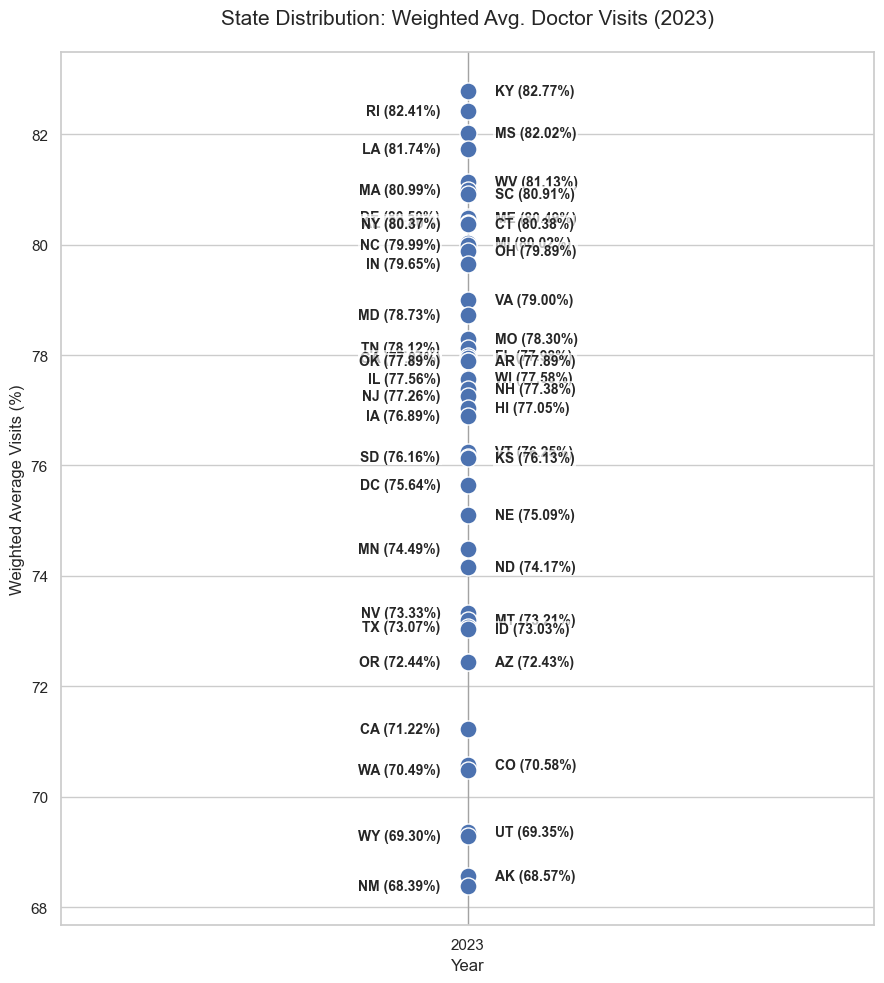

In [116]:
# 1. Filter for 2023 and calculate weighted averages
latest_year = 2023
df_2023 = df_merged[df_merged['year'] == latest_year].copy()

def get_weighted_avg(group):
    return np.average(group['doctor_visits_past_year'], weights=group['totalpopulation'])

df_state_2023 = df_2023.groupby('state').apply(get_weighted_avg).reset_index()
df_state_2023.columns = ['state', 'weighted_avg_visits']
df_state_2023['year'] = latest_year

# 2. Sort by value to make the alternating logic predictable
df_state_2023 = df_state_2023.sort_values('weighted_avg_visits', ascending=False).reset_index(drop=True)

# 3. Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 10)) # Increased height helps with vertical spacing

# Vertical reference line
plt.axvline(x=latest_year, color='black', linestyle='-', alpha=0.2, linewidth=1)

# Plot the points
sns.scatterplot(
    data=df_state_2023,
    x='year',
    y='weighted_avg_visits',
    s=150,
    legend=False,
    zorder=3
)

# 4. Alternating Label Logic
for idx, row in df_state_2023.iterrows():
    # If index is even, place on the right; if odd, place on the left
    if idx % 2 == 0:
        align = 'left'
        x_offset = 0.04
    else:
        align = 'right'
        x_offset = -0.04
    
    plt.text(
        row['year'] + x_offset,
        row['weighted_avg_visits'],
        f"{row['state']} ({row['weighted_avg_visits']:.2f}%)",
        va='center',
        ha=align,
        fontsize=10,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1) # Background for legibility
    )

# Formatting
plt.title(f'State Distribution: Weighted Avg. Doctor Visits ({latest_year})', fontsize=15, pad=20)
plt.ylabel('Weighted Average Visits (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)

# Set X-axis limits to make room for labels on both sides
plt.xlim(latest_year - 0.6, latest_year + 0.6)
plt.xticks([latest_year])

plt.tight_layout()
plt.show()

### National Weighted Average Visits

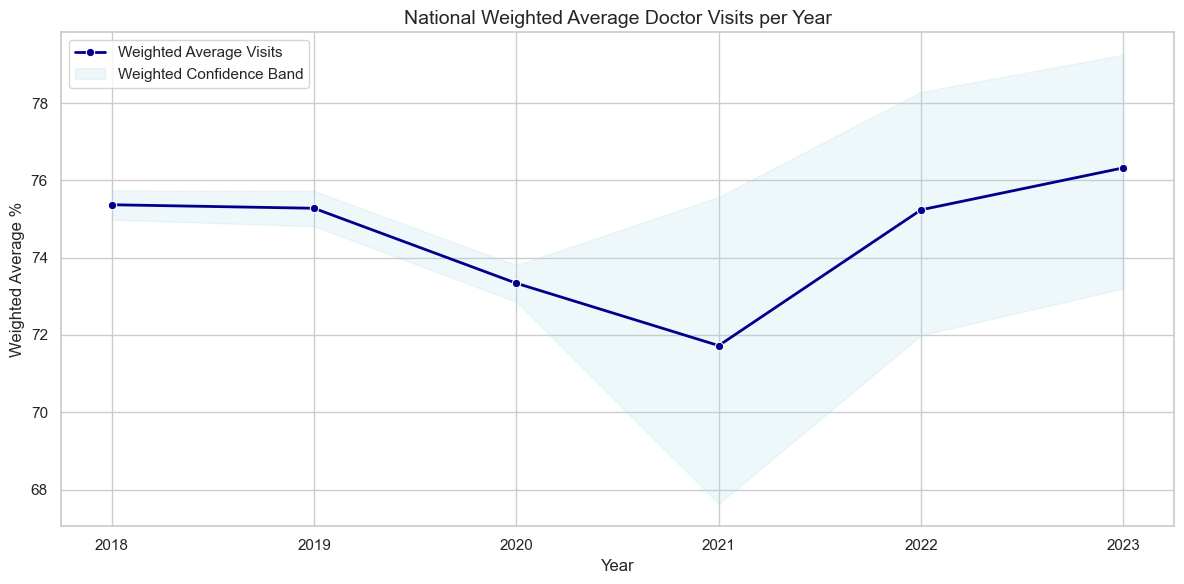

In [117]:
# Creating a helper function to calculate weighted average of doctor visits per year, weighted by total population
def weighted_stats(group):
    """Calculates weighted averages for the metric and its confidence limits."""
    w = group['totalpopulation']
    
    # Calculate weighted means for each column
    w_avg = np.average(group['doctor_visits_past_year'], weights=w)
    w_low = np.average(group['low_confidence_limit'], weights=w)
    w_high = np.average(group['high_confidence_limit'], weights=w)
    
    return pd.Series({
        'weighted_avg': w_avg,
        'weighted_low': w_low,
        'weighted_high': w_high
    })

# Calculate weighted average doctor visits per year
df_yearly_weighted = df_merged[['year','doctor_visits_past_year','totalpopulation','low_confidence_limit','high_confidence_limit']].groupby('year').apply(weighted_stats).reset_index()
df_yearly_weighted.head().columns = ['year', 'weighted_avg_visits','weighted_low','weighted_high']

# 2. Plotting with Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Weighted mean line
sns.lineplot(
    data=df_yearly_weighted, 
    x='year', 
    y='weighted_avg', 
    marker='o', 
    color='darkblue', 
    linewidth=2,
    label='Weighted Average Visits'
)

# Weighted confidence band
plt.fill_between(
    df_yearly_weighted['year'], 
    df_yearly_weighted['weighted_low'], 
    df_yearly_weighted['weighted_high'], 
    color='lightblue', 
    alpha=0.2, 
    label='Weighted Confidence Band'
)

# Formatting
plt.title('National Weighted Average Doctor Visits per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Weighted Average %', fontsize=12)
plt.xticks(df_yearly_weighted['year'].unique())
plt.legend()

plt.tight_layout()
plt.show()



### Box Plot of Average Doctor visits by zipcode

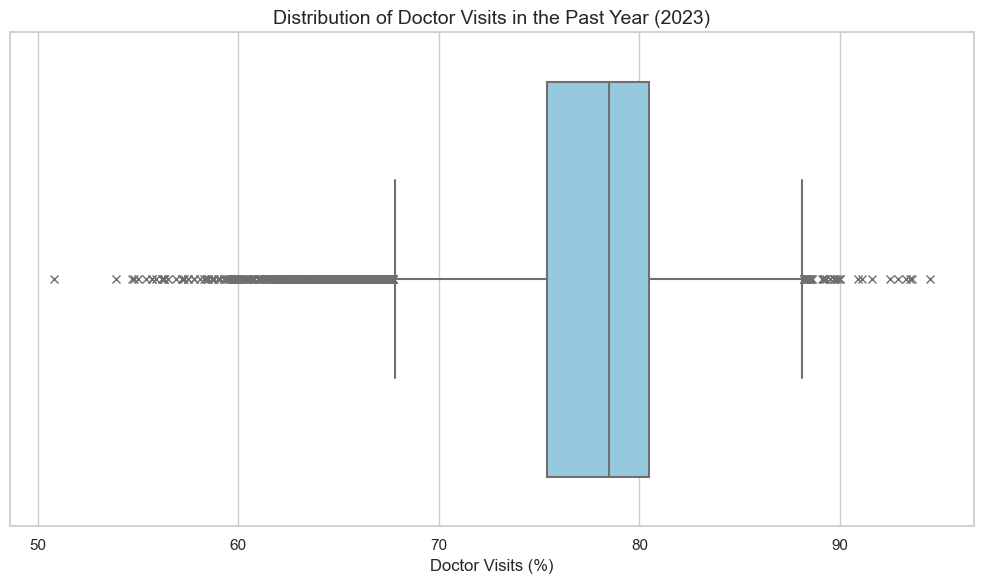

In [118]:
df_latest = df_merged[df_merged['year'] == latest_year]

# 2. Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the Box Plot
# Horizontal box plots make the X-axis labels (percentages) very easy to read
sns.boxplot(
    data=df_latest,
    x='doctor_visits_past_year',
    color='skyblue',        # Clean, legible color
    linewidth=1.5,
    flierprops={"marker": "x"} # Clearer marker for outliers
)

# 4. Formatting labels
plt.title(f'Distribution of Doctor Visits in the Past Year ({latest_year})', fontsize=14)
plt.xlabel('Doctor Visits (%)', fontsize=12)

plt.tight_layout()
plt.show()

### Box Plots of zipcode Average Doctor visits by state  

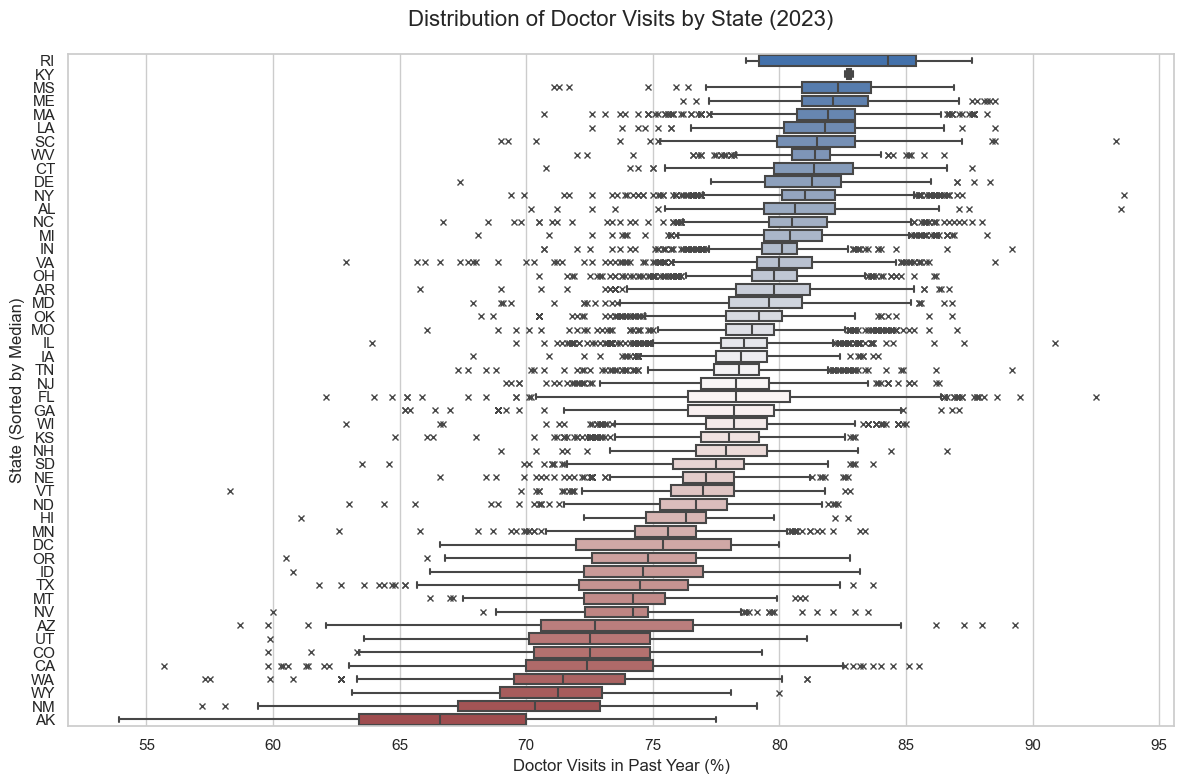

In [119]:
# 2. Determine the "Sensible" Order: Sort states by their median visit rate
state_order = df_latest.groupby('state')['doctor_visits_past_year'].median().sort_values(ascending=False).index

# 3. Visualization Setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8)) # Taller figure to accommodate state names

# 4. Create Horizontal Box Plots
sns.boxplot(
    data=df_latest,
    y='state',                     # Categorical on Y for horizontal layout
    x='doctor_visits_past_year',   # Numerical on X
    order=state_order,             # Apply the sorted ranking
    palette='vlag',                # Professional color gradient
    linewidth=1.5,
    flierprops={"marker": "x", "markersize": 5} # Clearer outliers
)

# 5. Formatting
plt.title(f'Distribution of Doctor Visits by State ({latest_year})', fontsize=16, pad=20)
plt.xlabel('Doctor Visits in Past Year (%)', fontsize=12)
plt.ylabel('State (Sorted by Median)', fontsize=12)

plt.tight_layout()
plt.show()

## Average Daily Population
### Summary Statistics

In [128]:
detainee_df = df_merged[df_merged['average_daily_population'] != 0].copy()
detainee_df['average_daily_population'].describe()

count    8538.000000
mean      186.164793
std       278.959235
min         1.000000
25%         9.000000
50%        66.000000
75%       246.750000
max      2050.000000
Name: average_daily_population, dtype: float64

### Latest Year's Average daily population by State

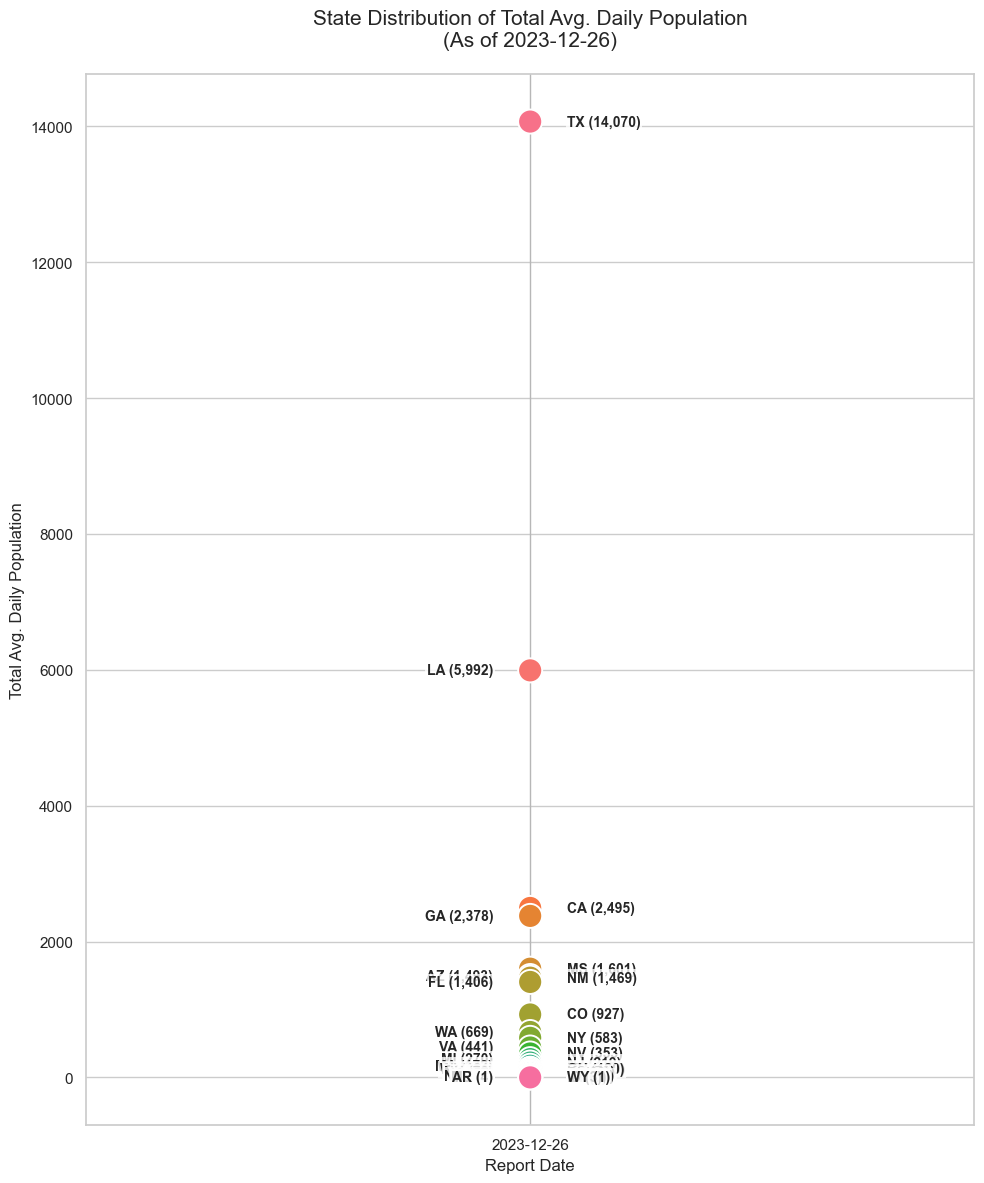

In [129]:
# 1. Identify the latest snapshot date
latest_date = detainee_df['current_as_of'].max()
df_latest = detainee_df[detainee_df['current_as_of'] == latest_date].copy()

# 2. Aggregate Total Avg Daily Population by State
df_state_pop = df_latest.groupby('state')['average_daily_population'].sum().reset_index()

# 3. Sort for visual hierarchy
df_state_pop = df_state_pop.sort_values('average_daily_population', ascending=False).reset_index(drop=True)

# 4. Plotting
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 12))

# Vertical line at the specific date
ax.axvline(x=latest_date, color='black', linestyle='-', alpha=0.1, linewidth=1)

# Scatter plot
sns.scatterplot(
    data=df_state_pop,
    x=[latest_date] * len(df_state_pop), # All points on the same date line
    y='average_daily_population',
    hue='state',
    s=300,
    legend=False,
    zorder=3
)

# 5. Non-overlapping Alternating Labels
for idx, row in df_state_pop.iterrows():
    # Toggle sides: Even on right, Odd on left
    if idx % 2 == 0:
        align = 'left'
        x_offset = pd.Timedelta(days=5) # Offset for datetime axis
    else:
        align = 'right'
        x_offset = pd.Timedelta(days=-5)
    
    ax.text(
        latest_date + x_offset,
        row['average_daily_population'],
        f"{row['state']} ({int(row['average_daily_population']):,})",
        va='center',
        ha=align,
        fontsize=10,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
    )

# Formatting
date_str = latest_date.strftime('%Y-%m-%d')
plt.title(f'State Distribution of Total Avg. Daily Population\n(As of {date_str})', fontsize=15, pad=20)
plt.ylabel('Total Avg. Daily Population', fontsize=12)
plt.xlabel('Report Date', fontsize=12)

# Adjust X-axis to show the date clearly and leave room for labels
plt.xlim(latest_date - pd.Timedelta(days=60), latest_date + pd.Timedelta(days=60))
plt.xticks([latest_date])

plt.tight_layout()
plt.show()

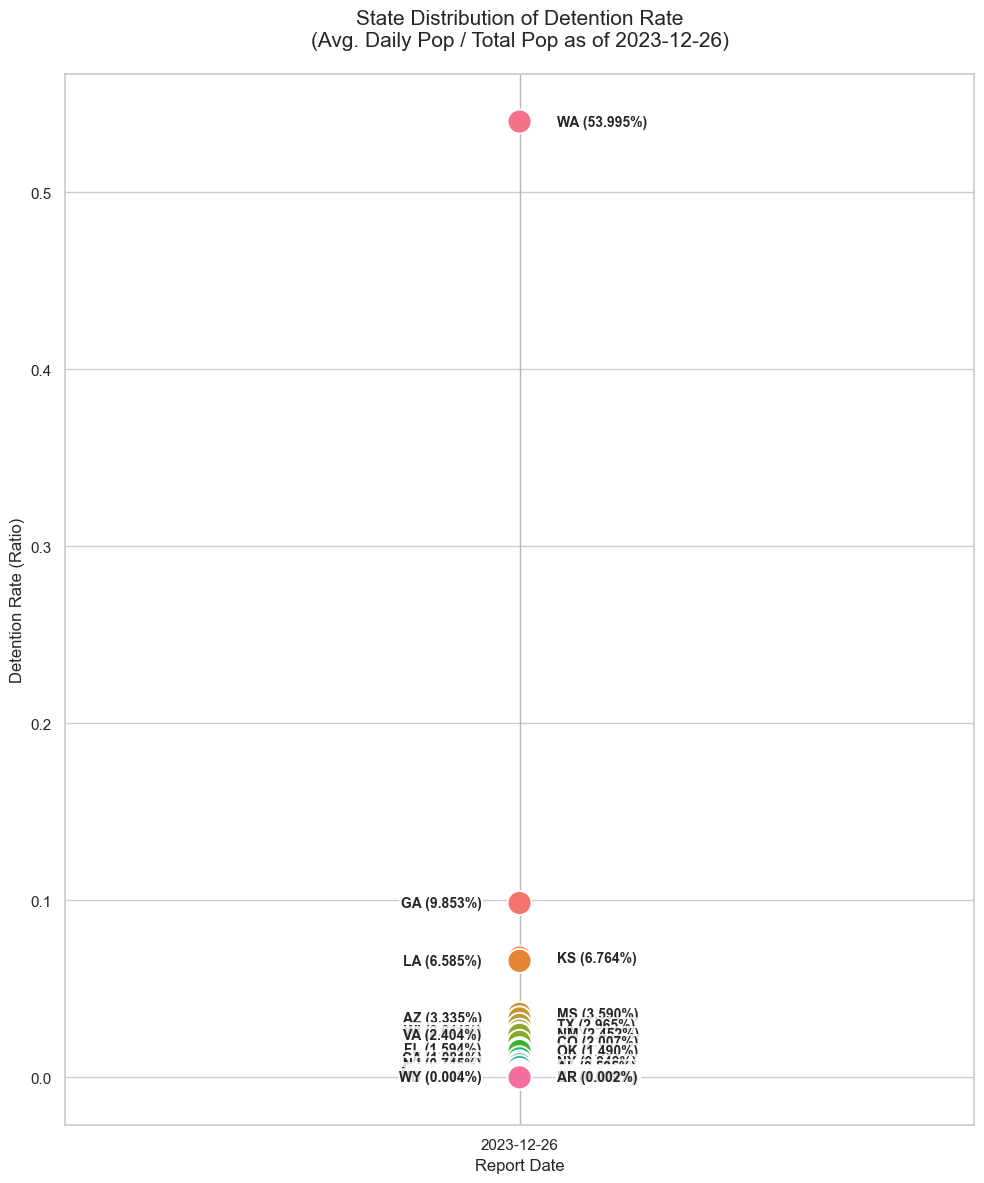

In [130]:
# 1. Identify the latest snapshot date
latest_date = detainee_df['current_as_of'].max()
df_latest = detainee_df[detainee_df['current_as_of'] == latest_date].copy()

# 2. Aggregate and Calculate State-level Ratio
# We sum both components first, then divide to get the true state-wide rate
df_state_metrics = df_latest.groupby('state').agg({
    'average_daily_population': 'sum',
    'totalpopulation': 'sum'
}).reset_index()

# Calculate detention rate (Detention Pop / Total Pop)
df_state_metrics['detention_rate'] = (
    df_state_metrics['average_daily_population'] / df_state_metrics['totalpopulation']
)

# 3. Sort by the NEW metric for visual hierarchy
df_state_metrics = df_state_metrics.sort_values('detention_rate', ascending=False).reset_index(drop=True)

# 4. Plotting
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 12))

# Reference line at the specific report date
ax.axvline(x=latest_date, color='black', linestyle='-', alpha=0.1, linewidth=1)

# Scatter plot using detention_rate on the Y-axis
sns.scatterplot(
    data=df_state_metrics,
    x=[latest_date] * len(df_state_metrics),
    y='detention_rate',
    hue='state',
    s=300,
    legend=False,
    zorder=3
)

# 5. Non-overlapping Alternating Labels
for idx, row in df_state_metrics.iterrows():
    # Toggle sides: Even on right, Odd on left
    if idx % 2 == 0:
        align = 'left'
        x_offset = pd.Timedelta(days=5) 
    else:
        align = 'right'
        x_offset = pd.Timedelta(days=-5)
    
    # Label formatting (shows state name and rate as a percentage)
    percentage = row['detention_rate'] * 100
    ax.text(
        latest_date + x_offset,
        row['detention_rate'],
        f"{row['state']} ({percentage:.3f}%)",
        va='center',
        ha=align,
        fontsize=10,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
    )

# Formatting
date_str = latest_date.strftime('%Y-%m-%d')
plt.title(f'State Distribution of Detention Rate\n(Avg. Daily Pop / Total Pop as of {date_str})', fontsize=15, pad=20)
plt.ylabel('Detention Rate (Ratio)', fontsize=12)
plt.xlabel('Report Date', fontsize=12)

# Adjust X-axis to show the date and leave room for labels
plt.xlim(latest_date - pd.Timedelta(days=60), latest_date + pd.Timedelta(days=60))
plt.xticks([latest_date])

plt.tight_layout()
plt.show()

In [131]:
df_latest[df_latest['state'] == 'WA']

,year,doctor_visits_past_year,low_confidence_limit,high_confidence_limit,totalpopulation,geolocation,zip,name,city,state,type_detailed,average_daily_population,current_as_of
193233,2023,62.7,59.7,65.4,1239,POINT (-122.4002088 47.2606371),98421,Tacoma Ice Processing Center (northwest Det Ctr),Tacoma,WA,CDF,669.0,2023-12-26


### National Weighted Average Population

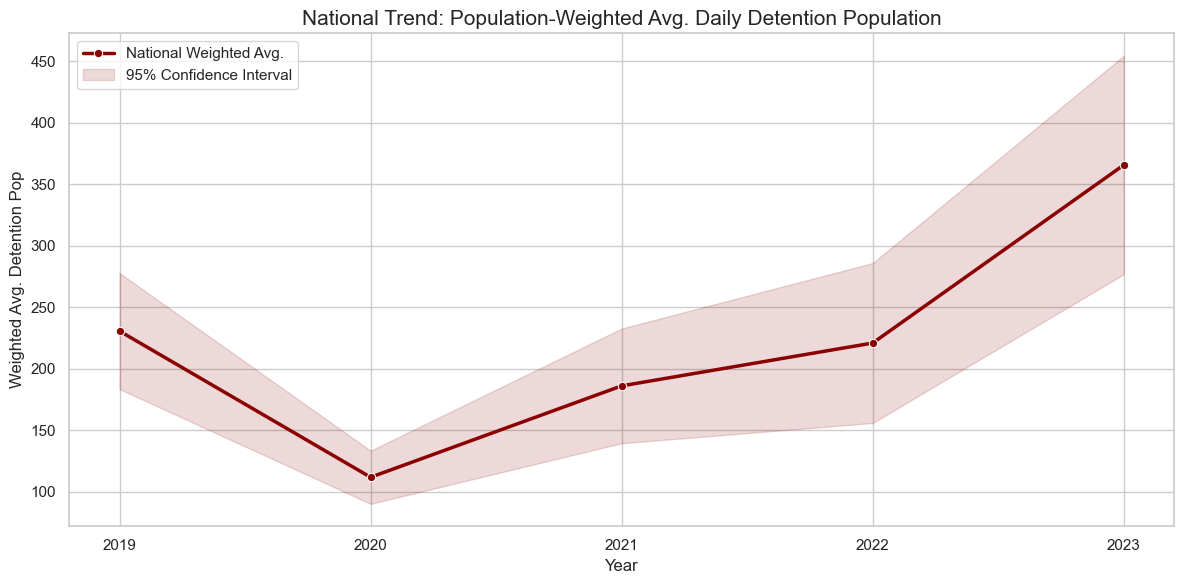

In [132]:
latest_dates = detainee_df.groupby(detainee_df['current_as_of'].dt.year)['current_as_of'].transform('max')
df_latest_yearly = detainee_df[detainee_df['current_as_of'] == latest_dates].copy()
df_latest_yearly['year_val'] = df_latest_yearly['current_as_of'].dt.year

# 3. Calculate National Weighted Average and Confidence Bands
def weighted_national_stats(group):
    d = group['average_daily_population']
    w = group['totalpopulation']
    
    # Calculate Weighted Mean
    w_avg = np.average(d, weights=w)
    
    # Calculate Weighted Standard Error for the band
    w_var = np.average((d - w_avg)**2, weights=w)
    w_std = np.sqrt(w_var)
    n = len(group)
    margin = 1.96 * (w_std / np.sqrt(n)) if n > 0 else 0
    
    return pd.Series({
        'national_w_avg': w_avg,
        'low_band': w_avg - margin,
        'high_band': w_avg + margin
    })

df_national_trend = df_latest_yearly.groupby('year_val').apply(weighted_national_stats).reset_index()

# 4. Create the line plot with confidence bands
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_national_trend,
    x='year_val',
    y='national_w_avg',
    marker='o',
    color='darkred',
    linewidth=2.5,
    label='National Weighted Avg.'
)

plt.fill_between(
    df_national_trend['year_val'],
    df_national_trend['low_band'],
    df_national_trend['high_band'],
    color='darkred',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('National Trend: Population-Weighted Avg. Daily Detention Population', fontsize=15)
plt.ylabel('Weighted Avg. Detention Pop', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks(df_national_trend['year_val'].unique())
plt.legend()

plt.tight_layout()
plt.show()

# Modeling

Analyze the relationship between immigration enforcement intensity and healthcare utilization.

## Model Specification

Define control variables and modeling approach.

In [88]:
# Modeling approach:
# - Panel regression with fixed effects
# - Control variables: socioeconomic status, demographics, healthcare infrastructure
# - Dependent variable: Healthcare utilization (routine checkup rates)
# - Independent variable: Immigration enforcement intensity (detention counts)
# - Subgroup analysis by citizenship status and facility type

print("Model specification code will go here")

Model specification code will go here


## Model Estimation

Run regression models and generate results.

In [89]:
# Convert to pandas for statsmodels
# panel_df = panel_data.toPandas()

# Fit regression model
# model = ols('healthcare_utilization ~ enforcement_intensity + controls', data=panel_df).fit()

# Display results
# print(model.summary())

print("Model estimation code will go here")

Model estimation code will go here


# Data Visualization

Create maps, scatter plots, and regression visualizations to illustrate findings.

## Geographic Distribution Maps (optional)

Create choropleth maps showing enforcement intensity and healthcare utilization across counties.

In [90]:
# Create geographic visualizations
# - Map 1: Immigration enforcement intensity by county
# - Map 2: Healthcare utilization rates by county
# - Map 3: Combined visualization showing correlation

print("Geographic visualization code will go here")

Geographic visualization code will go here


## Scatter Plots and Regression Lines

Visualize the relationship between enforcement intensity and healthcare utilization.

In [91]:
# Create scatter plots with regression lines
# - Overall relationship
# - By subgroups (citizenship status, facility type)
# - Time period comparisons

print("Scatter plot visualization code will go here")

Scatter plot visualization code will go here


## Time Series Analysis

Visualize trends in enforcement and healthcare utilization over time.

In [92]:
# Create time series visualizations
# - Trends in ICE enforcement activity (2015-2025)
# - Trends in healthcare utilization rates
# - Key policy change periods (e.g., January 2025 sensitive location policy)

print("Time series visualization code will go here")

Time series visualization code will go here


# Results Summary

Summary of key findings and implications for the research article.

In [93]:
# Key findings:
# 1. Geographic areas with high enforcement and low healthcare utilization
# 2. Statistical significance of the relationship
# 3. Subgroup differences
# 4. Policy implications

# Export results for inclusion in research article
print("Results summary and export code will go here")

# Note: This appendix supports the findings presented in:
# "Health Care Utilization and Immigration Enforcement" by Naomi Buell and Richie Rivera

Results summary and export code will go here
